# Stacking 集成学习算法流程

## 输入

- **训练集**: $D = \{ (x_i, y_i) \}_{i=1}^{N}$
- **基础学习器**: $M$ 个，记为 $f_1, f_2, ..., f_M$
- **元学习器**: $g$

---

## 训练阶段

### 1. 第一层：生成 OOF (Out-of-Fold) 元特征

1. 将训练集划分为 $K$ 折。
2. 对每个基础学习器 $f_m$：
    - 每次使用 $K-1$ 折数据进行训练。
    - 在剩下的 1 折数据上进行预测。
    - 将该折的验证预测值拼回原顺序，得到第 $m$ 个基础模型的 OOF 预测值：
      $$
      \hat{y}_{m,i}^{\text{OOF}} = f_m^{(-k(i))}(x_i)
      $$
      - 其中 $k(i)$ 表示样本 $x_i$ 所在的验证折。
      - $f_m^{(-k(i))}$ 表示没有使用第 $k(i)$ 折训练出的模型。
3. 对全部 $M$ 个基础模型重复此过程，得到元特征矩阵 $Z$：

$$
Z =
\begin{bmatrix}
\hat{y}_{1,1}^{\text{OOF}} & \hat{y}_{2,1}^{\text{OOF}} & \dots & \hat{y}_{M,1}^{\text{OOF}} \\
\hat{y}_{1,2}^{\text{OOF}} & \hat{y}_{2,2}^{\text{OOF}} & \dots & \hat{y}_{M,2}^{\text{OOF}} \\
\vdots & \vdots & \ddots & \vdots \\
\hat{y}_{1,N}^{\text{OOF}} & \hat{y}_{2,N}^{\text{OOF}} & \dots & \hat{y}_{M,N}^{\text{OOF}}
\end{bmatrix}
$$

### 2. 第二层：训练元学习器

- 将元特征矩阵 $Z$ 作为新的输入特征。
- 目标变量仍为原始标签 $Y$。
- 训练元学习器 $g$：
  $$
  g \leftarrow \text{Train}(Z, Y)
  $$

### 3. 重新训练基础模型

为了泛化到新样本，使用完整的训练集 $(X, Y)$ 重新训练每个基础模型：
$$
f_m \leftarrow \text{Train}(X, Y), \quad \forall m \in \{1, ..., M\}
$$

---

## 预测阶段

给定一个新样本 $x^*$：

1. **计算第一层模型的预测**：
   $$
   \hat{y}_m^* = f_m(x^*), \quad \forall m \in \{1, ..., M\}
   $$

2. **用元学习器综合预测**：
   $$
   \hat{y}^* = g(\hat{y}_1^*, \hat{y}_2^*, ..., \hat{y}_M^*)
   $$

3. **输出最终预测**：
   $\hat{y}^*$ 即为 Stacking 模型的最终预测值。

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, StackingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error

np.random.seed(42)

X, y = make_regression(n_samples=1000, n_features=20, noise=0.1)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

base_models = [
    ('rf', RandomForestRegressor(n_estimators=100, random_state=42)),
    ('gbr', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)),
    ('svr', SVR(C=1.0, epsilon=0.1))
]

In [4]:
ridge = Ridge()
param_grid = {
    'alpha': [0.1, 1.0, 10.0, 50.0, 100.0]
}
grid_search = GridSearchCV(ridge, param_grid, cv=5, scoring='neg_mean_squared_error')

In [5]:
stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator= ridge,
    cv=5
)

In [6]:
from sklearn.model_selection import cross_val_predict

X_meta = np.column_stack([
    cross_val_predict(model, X_train, y_train, cv=5) for _, model in base_models
])

grid_search.fit(X_meta, y_train)
best_alpha = grid_search.best_params_['alpha']
print("Best alpha for Ridge (meta learner):", best_alpha)

Best alpha for Ridge (meta learner): 100.0


In [7]:
grid_search.best_params_

{'alpha': 100.0}

In [8]:
optimized_ridge = Ridge(alpha=best_alpha)
optimized_stacking_model = StackingRegressor(
    estimators=base_models,
    final_estimator=optimized_ridge,
    cv=5
)

optimized_stacking_model.fit(X_train, y_train)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.","[('rf', ...), ('gbr', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA regressor which will be used to combine the base estimators.The default regressor is a :class:`~sklearn.linear_model.RidgeCV`.",Ridge(alpha=100.0)
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_sample

In [11]:
from sklearn.metrics import r2_score
y_pred = optimized_stacking_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2_score = r2_score(y_test, y_pred)
print(f"Test Mean Squared Error: {mse:.2f}")
print(f"Test R2 Score: {r2_score:.2f}")

Test Mean Squared Error: 1982.56
Test R2 Score: 0.95


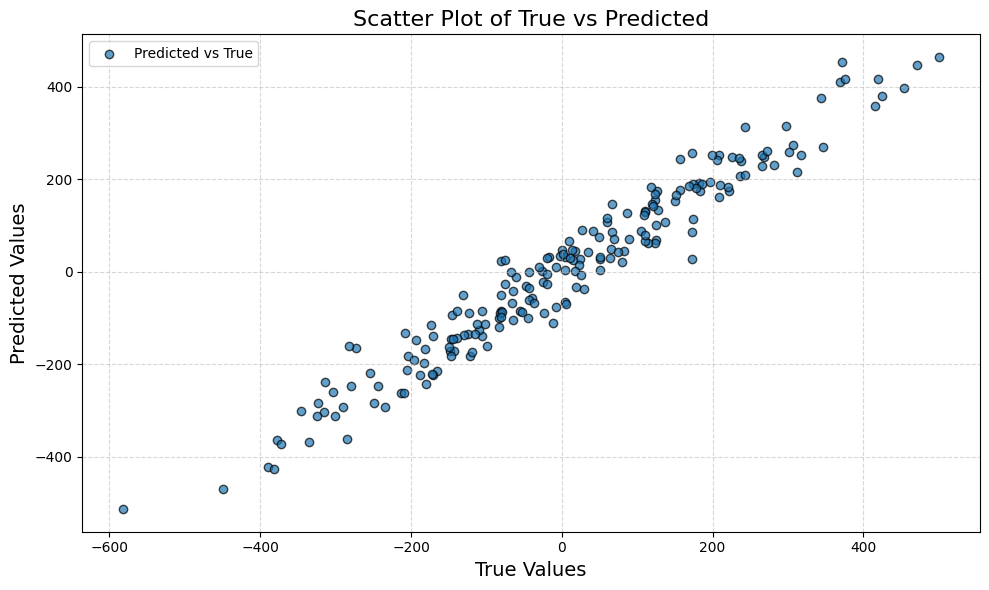

In [12]:
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='tab:blue', alpha=0.7, edgecolor='k', label='Predicted vs True')
plt.xlabel('True Values', fontsize=14)
plt.ylabel('Predicted Values', fontsize=14)
plt.title('Scatter Plot of True vs Predicted', fontsize=16)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

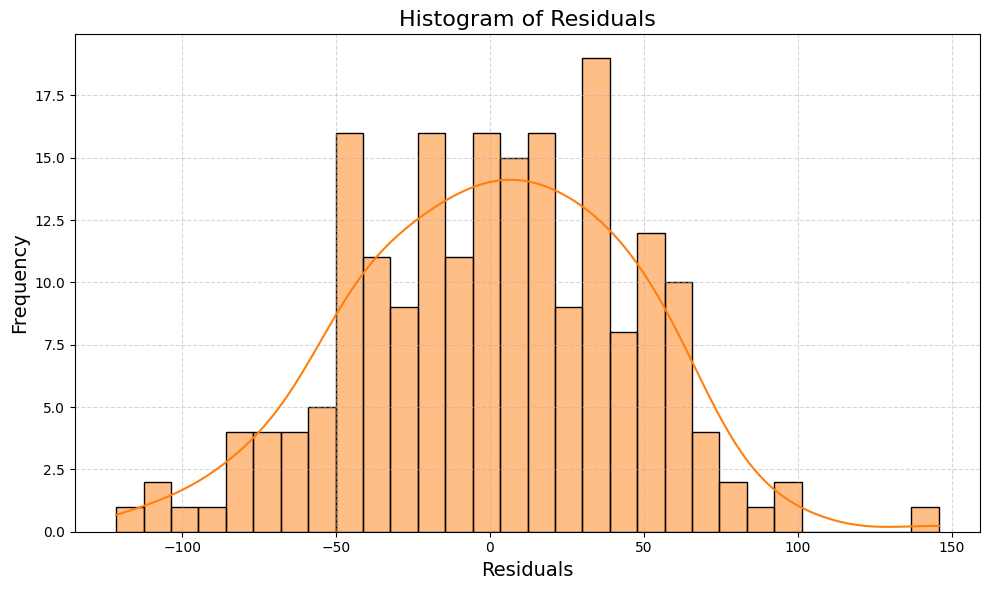

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True, color='tab:orange', bins=30)
plt.xlabel('Residuals', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.title('Histogram of Residuals', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## Stacking 集成方法优缺点

### 优点

- **利用多个模型的优势**：堆叠集成多个基础模型，结合它们的长处，提高泛化能力。比如，随机森林能处理非线性和特征交互，梯度提升回归擅长逐步修正残差，SVM 在某些中小规模数据上也很有竞争力。

- **融合规则可学习**：相比固定平均或投票，Stacking 可以让元学习器学习不同基础模型的贡献。前提是元特征生成方式正确，否则学到的可能只是训练集上的过拟合痕迹。

- **灵活性强**：可以搭配各种基础学习器，并使用任意复杂的元学习器（如线性回归、XGBoost、深度学习模型），适用于各种任务。

- **可调优**：使用交叉验证 + 超参数优化（如 GridSearchCV）来优化元学习器，使得最终模型更具鲁棒性。

### 缺点

- **计算成本高**：训练多个基础模型 + 训练一个元学习器，计算开销大，训练和预测时间较长。

- **难以解释**：相较于单个模型（如线性回归），Stacking 的层次化结构较难解释，可解释性较差。

- **依赖于基础模型表现**：如果基础模型本身表现不好，Stacking 也无法显著提高性能，甚至可能降低模型效果。

- **信息泄露风险**：如果没有正确使用交叉验证来生成第一层预测值，可能会发生信息泄露，导致过拟合。

## 何时优选 Stacking，何时使用其他算法？

### 优选 Stacking 的情况

- **数据量和计算资源都够用**：Stacking 需要训练多个基础模型，还要生成 OOF 预测，计算量不低。
- **需要结合多种模型优点**：当单一模型无法很好地拟合数据时，使用多个模型的 Stacking 可能会提供更好的结果。
- **任务对准确性要求高**：如 Kaggle 竞赛、金融预测等，需要极致的预测精度，而非可解释性。
- **数据异质性较高**：如果数据的模式复杂，可能需要不同的模型捕捉不同的特征，这时 Stacking 比 Bagging 或 Boosting 更有效。

### 优选其他方法的情况

- **计算资源有限**（选择 Bagging）：如果计算能力有限但仍希望降低方差，Bagging（如随机森林）是更好的选择。
- **需要较强的单模型方案**（选择 Boosting）：如果希望先得到一个强大的结构化数据模型，可以选择 Boosting（如 XGBoost、LightGBM）。它们未必总是更快，但工程成熟度高、调参路径清晰。
- **需要高可解释性**（选择线性模型或决策树）：如果任务对模型的可解释性要求较高（如医疗、生物学领域），Boosting 或 Bagging 比 Stacking 更合适，甚至可以选择简单的线性模型或决策树。
- **数据量较小**（谨慎使用 Blending）：Blending 会拿出一块验证集训练元学习器，流程更轻，但小数据场景下留出验证集也会让基础模型少见一部分样本，所以要结合交叉验证一起判断。